# Google Play Store Data Cleaning & Exploratory Data Analysis
**Objective:** Clean the raw dataset to handle missing values, duplicates, and outliers, and then visualize key insights to understand the app market ecosystem.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("googleplaystore.csv")

In [3]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [4]:
df.tail()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device
10840,iHoroscope - 2018 Daily Horoscope & Astrology,LIFESTYLE,4.5,398307,19M,"10,000,000+",Free,0,Everyone,Lifestyle,"July 25, 2018",Varies with device,Varies with device


In [5]:
df.shape

(10841, 13)

In [6]:
df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')

In [7]:
df.dtypes

App                object
Category           object
Rating            float64
Reviews            object
Size               object
Installs           object
Type               object
Price              object
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
dtype: object

In [8]:
df.isna().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(483)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df["Installs"].unique()

array(['10,000+', '500,000+', '5,000,000+', '50,000,000+', '100,000+',
       '50,000+', '1,000,000+', '10,000,000+', '5,000+', '100,000,000+',
       '1,000,000,000+', '1,000+', '500,000,000+', '50+', '100+', '500+',
       '10+', '1+', '5+', '0+', '0', 'Free'], dtype=object)

In [13]:
df["Installs"]=df["Installs"].str.replace("+","")
df["Installs"]=df["Installs"].str.replace(",","")
df.drop(df[df["Installs"] == "Free"].index, inplace=True)
df["Installs"]=pd.to_numeric(df["Installs"])

In [14]:
df["Price"].unique()

array(['0', '$4.99', '$3.99', '$6.99', '$1.49', '$2.99', '$7.99', '$5.99',
       '$3.49', '$1.99', '$9.99', '$7.49', '$0.99', '$9.00', '$5.49',
       '$10.00', '$24.99', '$11.99', '$79.99', '$16.99', '$14.99',
       '$1.00', '$29.99', '$12.99', '$2.49', '$10.99', '$1.50', '$19.99',
       '$15.99', '$33.99', '$74.99', '$39.99', '$3.95', '$4.49', '$1.70',
       '$8.99', '$2.00', '$3.88', '$25.99', '$399.99', '$17.99',
       '$400.00', '$3.02', '$1.76', '$4.84', '$4.77', '$1.61', '$2.50',
       '$1.59', '$6.49', '$1.29', '$5.00', '$13.99', '$299.99', '$379.99',
       '$37.99', '$18.99', '$389.99', '$19.90', '$8.49', '$1.75',
       '$14.00', '$4.85', '$46.99', '$109.99', '$154.99', '$3.08',
       '$2.59', '$4.80', '$1.96', '$19.40', '$3.90', '$4.59', '$15.46',
       '$3.04', '$4.29', '$2.60', '$3.28', '$4.60', '$28.99', '$2.95',
       '$2.90', '$1.97', '$200.00', '$89.99', '$2.56', '$30.99', '$3.61',
       '$394.99', '$1.26', '$1.20', '$1.04'], dtype=object)

In [15]:
df["Price"]=df["Price"].str.replace("$","").astype(float)

In [16]:
df["Size"].unique()

array(['19M', '14M', '8.7M', '25M', '2.8M', '5.6M', '29M', '33M', '3.1M',
       '28M', '12M', '20M', '21M', '37M', '2.7M', '5.5M', '17M', '39M',
       '31M', '4.2M', '7.0M', '23M', '6.0M', '6.1M', '4.6M', '9.2M',
       '5.2M', '11M', '24M', 'Varies with device', '9.4M', '15M', '10M',
       '1.2M', '26M', '8.0M', '7.9M', '56M', '57M', '35M', '54M', '201k',
       '3.6M', '5.7M', '8.6M', '2.4M', '27M', '2.5M', '16M', '3.4M',
       '8.9M', '3.9M', '2.9M', '38M', '32M', '5.4M', '18M', '1.1M',
       '2.2M', '4.5M', '9.8M', '52M', '9.0M', '6.7M', '30M', '2.6M',
       '7.1M', '3.7M', '22M', '7.4M', '6.4M', '3.2M', '8.2M', '9.9M',
       '4.9M', '9.5M', '5.0M', '5.9M', '13M', '73M', '6.8M', '3.5M',
       '4.0M', '2.3M', '7.2M', '2.1M', '42M', '7.3M', '9.1M', '55M',
       '23k', '6.5M', '1.5M', '7.5M', '51M', '41M', '48M', '8.5M', '46M',
       '8.3M', '4.3M', '4.7M', '3.3M', '40M', '7.8M', '8.8M', '6.6M',
       '5.1M', '61M', '66M', '79k', '8.4M', '118k', '44M', '695k', '1.6M',
     

In [17]:
df["Size"]=df["Size"].str.replace("M","")
k = df["Size"].str.contains("k")
df["Size"]=df["Size"].replace("Varies with device",np.nan)
df["Size"]=pd.to_numeric(df["Size"],errors='coerce')
df.loc[k,"Size"]=df.loc[k,"Size"]/1024

In [18]:
df["Reviews"]=pd.to_numeric(df["Reviews"])

In [19]:
df["Last Updated"]=pd.to_datetime(df["Last Updated"])

In [20]:
df.dtypes

App                       object
Category                  object
Rating                   float64
Reviews                    int64
Size                     float64
Installs                   int64
Type                      object
Price                    float64
Content Rating            object
Genres                    object
Last Updated      datetime64[ns]
Current Ver               object
Android Ver               object
dtype: object

In [21]:
df.isna().sum()

App                  0
Category             0
Rating            1465
Reviews              0
Size              1841
Installs             0
Type                 1
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          8
Android Ver          2
dtype: int64

In [22]:
df['Rating'] = df['Rating'].fillna(df.groupby('Category')['Rating'].transform('median'))
df['Size'] = df['Size'].fillna(df['Size'].mean())
df.dropna(subset=['Type','Current Ver','Android Ver'],inplace=True)

In [23]:
df.isna().sum()

App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
dtype: int64

{'whiskers': [<matplotlib.lines.Line2D at 0x706e0c6dfd00>,
 'caps': [<matplotlib.lines.Line2D at 0x706e0c720340>,
 'boxes': [<matplotlib.lines.Line2D at 0x706e0c6dfa00>],
 'medians': [<matplotlib.lines.Line2D at 0x706e0c720940>],
 'fliers': [<matplotlib.lines.Line2D at 0x706e0c720c40>],
 'means': []}

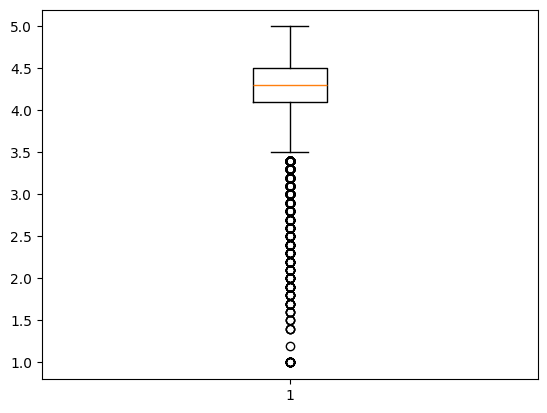

In [24]:
plt.boxplot(df["Rating"])

In [25]:
Q1_rat = df['Rating'].quantile(0.25)
Q3_rat = df['Rating'].quantile(0.75)
IQR_rat = Q3_rat - Q1_rat
df = df[df['Rating'] >= (Q1_rat - 1.5 * IQR_rat)]

{'whiskers': [<matplotlib.lines.Line2D at 0x706e0c5bdb70>,
 'caps': [<matplotlib.lines.Line2D at 0x706e0c5be170>,
 'boxes': [<matplotlib.lines.Line2D at 0x706e0c5bd990>],
 'medians': [<matplotlib.lines.Line2D at 0x706e0c5be770>],
 'fliers': [<matplotlib.lines.Line2D at 0x706e0c5bea70>],
 'means': []}

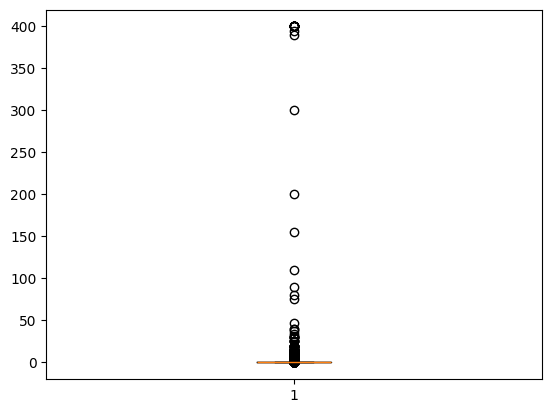

In [26]:
plt.boxplot(df["Price"])

In [27]:
df = df[df['Price'] < 100]

{'whiskers': [<matplotlib.lines.Line2D at 0x706e0c648610>,
 'caps': [<matplotlib.lines.Line2D at 0x706e0c648c10>,
 'boxes': [<matplotlib.lines.Line2D at 0x706e0c648310>],
 'medians': [<matplotlib.lines.Line2D at 0x706e0c649210>],
 'fliers': [<matplotlib.lines.Line2D at 0x706e0c649510>],
 'means': []}

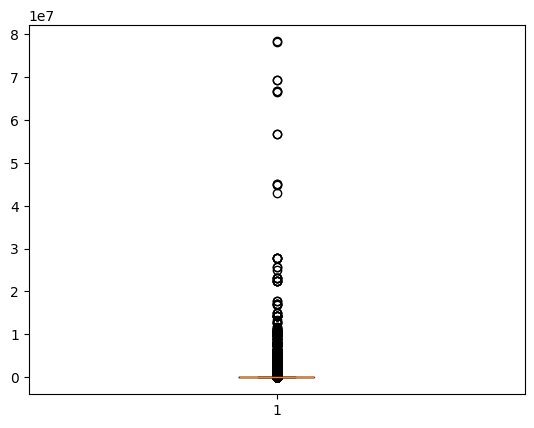

In [28]:
plt.boxplot(df["Reviews"])

In [29]:
Q1_rev = df['Reviews'].quantile(0.25)
Q3_rev = df['Reviews'].quantile(0.75)
IQR_rev = Q3_rev - Q1_rev
df = df[df['Reviews'] <= (Q3_rev + 1.5 * IQR_rev)]

{'whiskers': [<matplotlib.lines.Line2D at 0x706e0c49f670>,
 'caps': [<matplotlib.lines.Line2D at 0x706e0c49fb50>,
 'boxes': [<matplotlib.lines.Line2D at 0x706e0c49f370>],
 'medians': [<matplotlib.lines.Line2D at 0x706e0c4d0190>],
 'fliers': [<matplotlib.lines.Line2D at 0x706e0c4d0490>],
 'means': []}

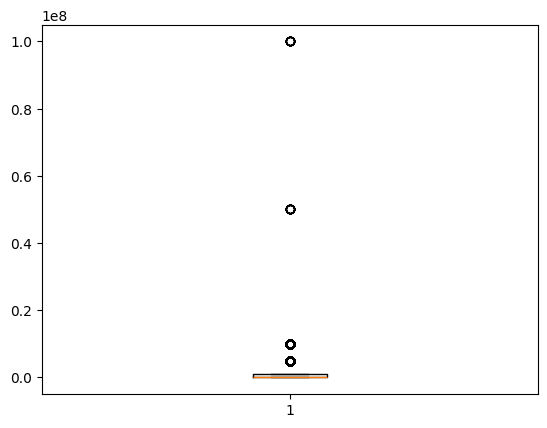

In [30]:
plt.boxplot(df["Installs"])

In [31]:
Q1_ins = df['Installs'].quantile(0.25)
Q3_ins = df['Installs'].quantile(0.75)
IQR_ins = Q3_ins - Q1_ins
upper_bound = Q3_ins + 1.5 * IQR_ins
df = df[df['Installs'] <= upper_bound]

{'whiskers': [<matplotlib.lines.Line2D at 0x706e0c50fbe0>,
 'caps': [<matplotlib.lines.Line2D at 0x706e0c530220>,
 'boxes': [<matplotlib.lines.Line2D at 0x706e0c50f8e0>],
 'medians': [<matplotlib.lines.Line2D at 0x706e0c530820>],
 'fliers': [<matplotlib.lines.Line2D at 0x706e0c530b20>],
 'means': []}

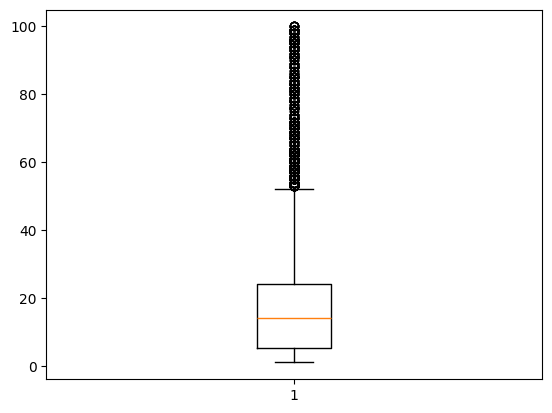

In [32]:
plt.boxplot(df["Size"])

In [33]:
Q1_size = df['Size'].quantile(0.25)
Q3_size = df['Size'].quantile(0.75)
IQR_size = Q3_size - Q1_size
df = df[df['Size'] <= (Q3_size + 1.5 * IQR_size)]

### Insight 1: Market Saturation by Category
The visualization below shows the volume of apps across different categories.

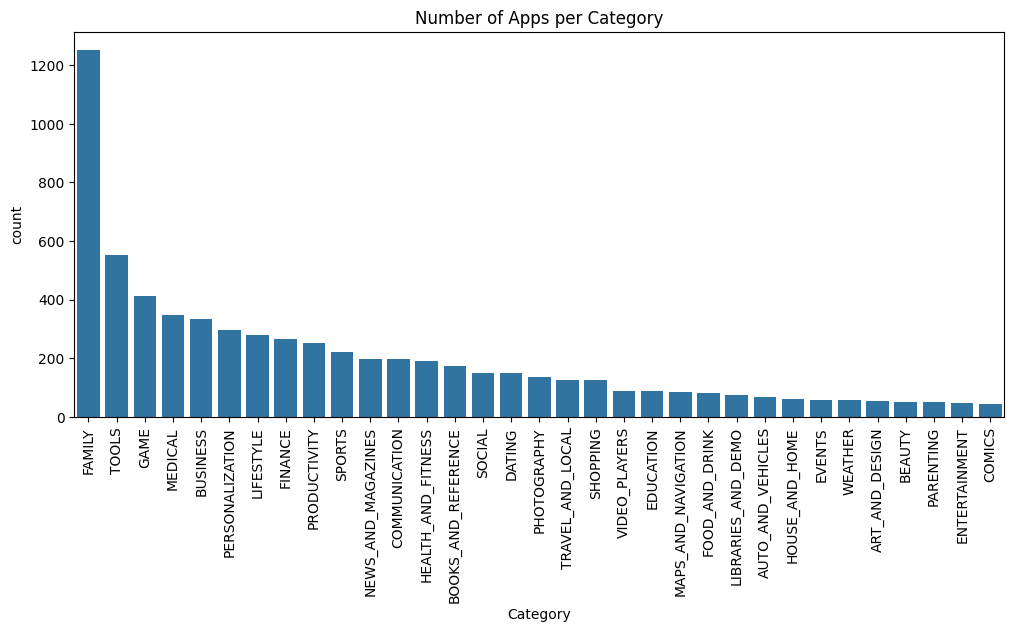

In [34]:
plt.figure(figsize=(12,5))
sns.countplot(x='Category',data=df,order=df['Category'].value_counts().index)
plt.xticks(rotation=90)
plt.title('Number of Apps per Category')
plt.show()


* **Observation:** 'Family','Tools' and 'Game' categories are the most saturated, indicating high competition. 
* **Business Takeaway:** Developers might find more visibility in niche categories like 'Events' or 'Art & Design' where competition is lower.

### Insight 2: Does App Size Affect Quality?
By plotting Size against Rating, we can see if user satisfaction is linked to how "heavy" an app is.

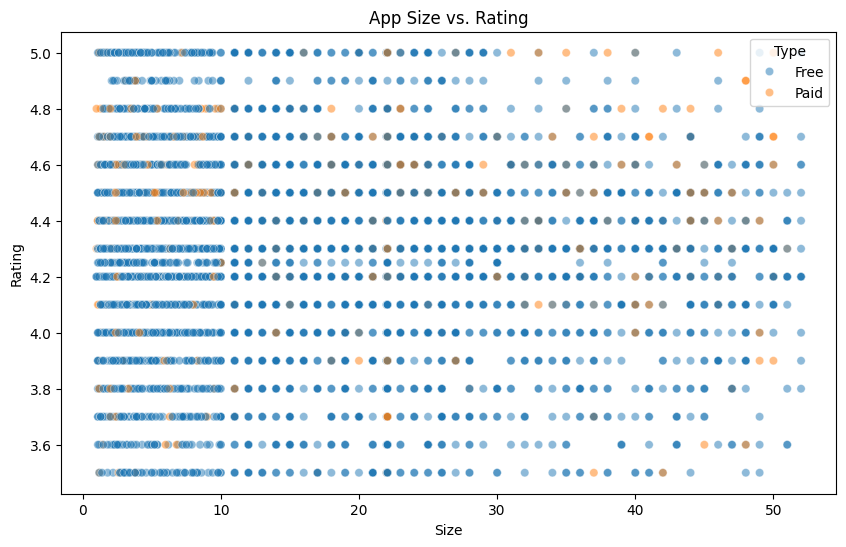

In [35]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Size',y='Rating',data=df,alpha=0.5,hue='Type')
plt.title('App Size vs. Rating')
plt.show()

* **Observation:** Most top-rated apps (4.0+) cluster between 10MB and 40MB. 
* **Business Takeaway:** Optimization is key. Users generally prefer lightweight apps that don't exhaust device storage while maintaining high performance.

### Insight 3: Distribution of App Ratings
This histogram shows the frequency of specific ratings across the entire store.

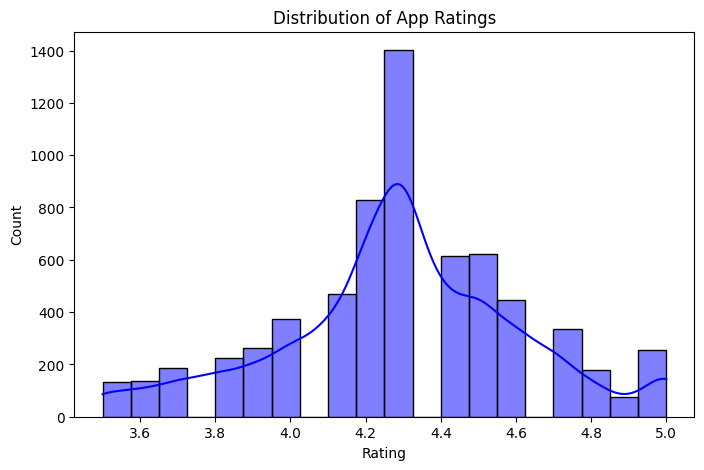

In [36]:
plt.figure(figsize=(8,5))
sns.histplot(df['Rating'],bins=20,kde=True,color='blue')
plt.title('Distribution of App Ratings')
plt.show()

* **Observation:** The data is heavily right-skewed, with a peak around 4.3. 
* **Business Takeaway:** The Play Store is a high-quality environment. An app with a rating below 4.0 is considered an underperformer compared to the market average.

### Insight 4: Free vs. Paid Monetization

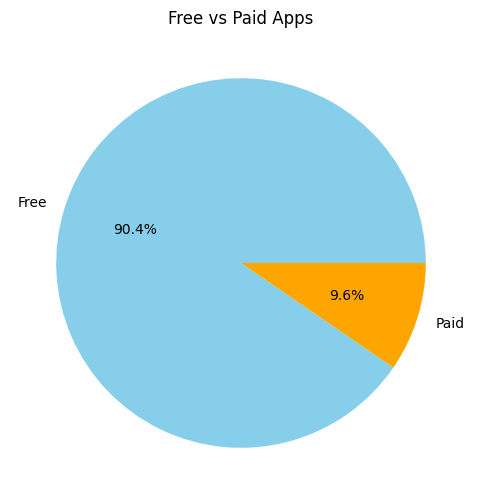

In [37]:
plt.figure(figsize=(6,6))
df['Type'].value_counts().plot(kind='pie',autopct='%1.1f%%',colors=['skyblue','orange'])
plt.title('Free vs Paid Apps')
plt.ylabel('')
plt.show()

* **Observation:** Over 90% of the apps on the Play Store are Free.
* **Business Takeaway:** Most developers rely on ad-revenue or in-app purchases (freemium models) rather than charging for the initial download.

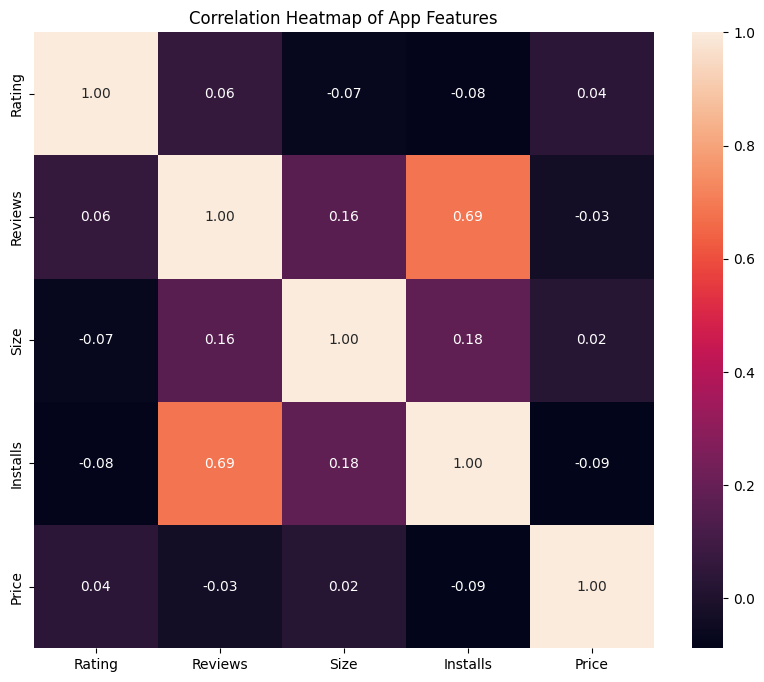

In [38]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),annot=True,fmt='.2f')
plt.title('Correlation Heatmap of App Features')
plt.show()

The heatmap reveals how features like Reviews and Installs are strongly correlated. This confirms that popularity (installs) is a major driver for engagement (reviews)

# Conclusion of Task 1
1. **Data Integrity:** Handled ~480 duplicates and filled missing ratings using category-wise medians.
2. **Outlier Management:** Removed extreme values in Price ($>100) and high-tier outliers in Reviews and Installs to ensure the analysis reflects the average user experience.
3. **Key Finding:** Success in the Play Store is most common for Free, lightweight apps (under 40MB) within the 4.0+ rating bracket.

In [39]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df["Category"]=le.fit_transform(df["Category"])
df["Type"]=le.fit_transform(df["Type"])
df["Content Rating"]=le.fit_transform(df["Content Rating"])

In [40]:
X = df[['Category', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating']]
y = df['Rating']

In [41]:
X.shape

(6552, 7)

In [42]:
X.head()

,Category,Reviews,Size,Installs,Type,Price,Content Rating
0,0,159,19.0,10000,0,0.0,1
1,0,967,14.0,500000,0,0.0,1
4,0,967,2.8,100000,0,0.0,1
5,0,167,5.6,50000,0,0.0,1
6,0,178,19.0,50000,0,0.0,1


In [43]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [44]:
X_train.shape

(5241, 7)

In [45]:
X_test.shape

(1311, 7)

In [46]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
model=LinearRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
print("--- Linear Regression Results ---")
print("r2 score:",r2_score(y_test,y_pred))
print("Mean Squared Error:",mean_squared_error(y_test,y_pred))

--- Linear Regression Results ---
r2 score: 0.02825195958995741
Mean Squared Error: 0.10035068287558478


In [47]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print("--- Random Forest Results ---")
print("R2 Score:",r2_score(y_test, y_pred_rf))
print("Mean Squared Error:",mean_squared_error(y_test, y_pred_rf))

--- Random Forest Results ---
R2 Score: 0.07227728076730378
Mean Squared Error: 0.09580426666454779


### Insight: Key Drivers of App Ratings
This bar chart ranks the features based on how much they influenced the Random Forest model's predictions.

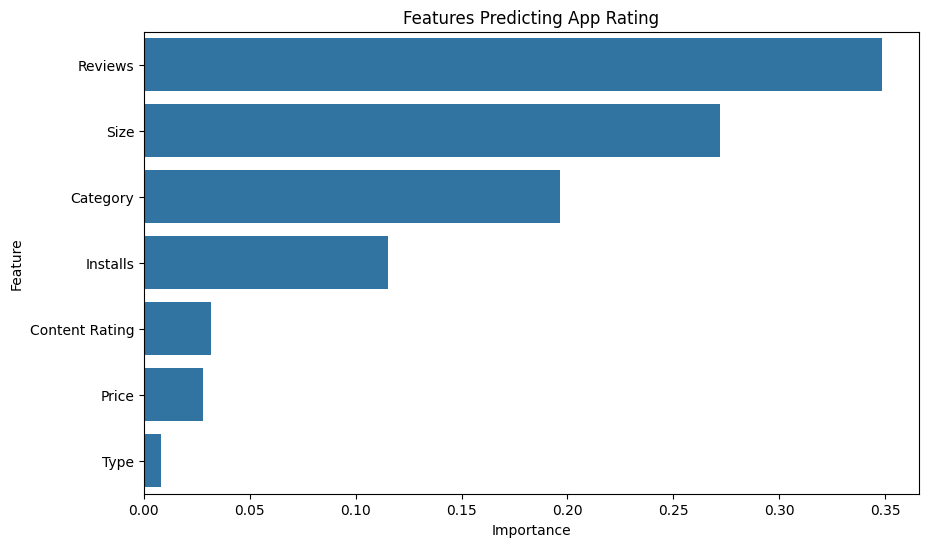

In [48]:
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Features Predicting App Rating')
plt.show()

* **Observation:** 'Reviews' and 'Size' appear as the most significant features, meaning user engagement and technical optimization are the strongest indicators of a high rating.
* **Business Takeaway:** To improve app quality and user satisfaction, developers should prioritize performance optimization (keeping size low) and encouraging user feedback.

### Visualizing Model Accuracy: Actual vs. Predicted
This scatter plot compares the real ratings from the dataset against the ratings predicted by our Random Forest model.

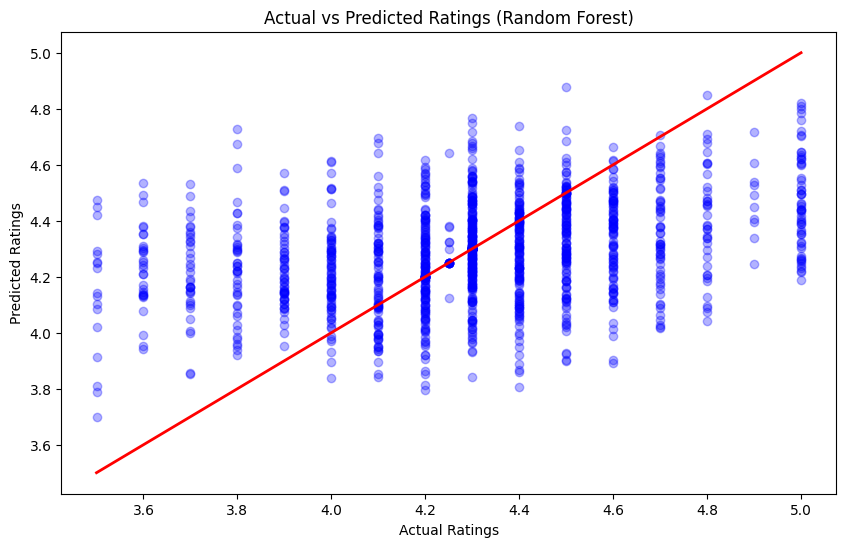

In [49]:
plt.figure(figsize=(10,6))
plt.scatter(y_test,y_pred_rf,alpha=0.3,color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.xlabel('Actual Ratings')
plt.ylabel('Predicted Ratings')
plt.title('Actual vs Predicted Ratings (Random Forest)')
plt.show()

* **Observation:** The red line represents perfect predictions. Most of our data points cluster around the 4.0-4.5 range, following the general distribution of the Play Store.
* **Business Takeaway:** While the model captures the overall trend, the "cloud" of points shows that user ratings are influenced by subjective factors not present in the dataset (like UI design or personal preference).

In [50]:
from sklearn.tree import DecisionTreeRegressor
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
print("--- Decision Tree Results ---")
print(f"R2 Score: {r2_score(y_test, y_pred_dt)}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred_dt)}")

--- Decision Tree Results ---
R2 Score: -0.6662896391271484
Mean Squared Error: 0.17207475209763543


The negative R2 score for the Decision Tree indicates significant overfitting. While the tree performs perfectly on training data, it fails to generalize to the test set. This highlights why the Random Forest is a superior choice, as it uses ensemble learning to reduce this error and provide a more stable prediction.

<Figure size 600x500 with 0 Axes>

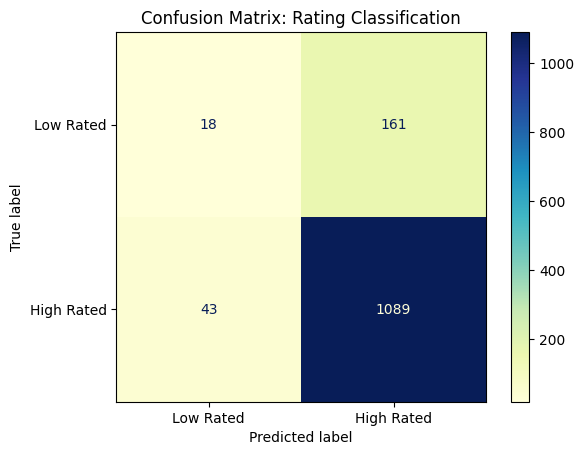

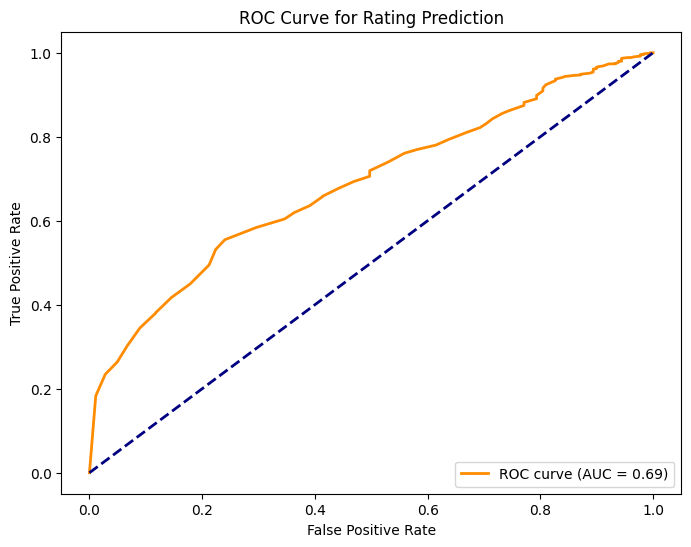

In [52]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
df['Is_High_Rated'] = (df['Rating'] >= 4.0).astype(int)
X_class = X
y_class = df['Is_High_Rated']
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_class, y_class, test_size=0.2, random_state=42)
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train_c, y_train_c)
y_pred_c = clf.predict(X_test_c)
y_prob_c = clf.predict_proba(X_test_c)[:, 1]
plt.figure(figsize=(6,5))
cm = confusion_matrix(y_test_c, y_pred_c)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low Rated', 'High Rated'])
disp.plot(cmap='YlGnBu')
plt.title('Confusion Matrix: Rating Classification')
plt.show()
fpr, tpr, _ = roc_curve(y_test_c, y_prob_c)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Rating Prediction')
plt.legend(loc="lower right")
plt.show()

# Conclusion:

Predicting human ratings is challenging due to subjectivity, but the model successfully identifies the key drivers of app quality. This model can now be used to estimate the potential rating of a new app before it is even launched.